# 📧 Email / SMS Spam Detection using Machine Learning

## 📌 Project Overview

This project focuses on detecting whether a text message is **Spam** or **Ham (Legitimate)** using Natural Language Processing (NLP) and Machine Learning.

The project uses the SMS Spam Collection dataset and applies text preprocessing, TF-IDF feature extraction, and supervised machine learning classification algorithms.

## 🎯 Objectives

- Load and explore the SMS Spam Collection dataset
- Clean and preprocess text messages
- Analyze the distribution of Spam and Ham messages
- Convert text into numerical features using TF-IDF
- Train multiple classification models
- Evaluate models using Accuracy, Precision, Recall, and F1-Score
- Visualize confusion matrices
- Compare model performance
- Select and save the best-performing model
- Perform error analysis on misclassified messages

## 📚 Dataset

The **SMS Spam Collection** dataset contains labeled text messages classified into two categories:

- **Ham** — legitimate/non-spam message
- **Spam** — unwanted or promotional message

The original dataset is stored as a tab-separated text file named `SMSSpamCollection`.

Each record contains:

1. Message label
2. Message text

The dataset will be loaded using Pandas with a tab (`\t`) as the separator.

In [1]:
# Import required libraries

import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Loading the Dataset

The dataset is stored inside the project's `data` folder.

Since the dataset is provided as a tab-separated text file rather than a CSV file, `sep="\t"` is used while loading it.

Two columns will be created:

- `label` — Spam or Ham
- `message` — Original text message

In [2]:
# Locate the dataset

possible_paths = [
    Path("data/SMSSpamCollection"),
    Path("DataScience-Task4-EmailSpamDetection/data/SMSSpamCollection")
]

DATA_PATH = None

for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "SMSSpamCollection was not found. "
        "Please make sure it is inside the Task 4 data folder."
    )

# Load dataset
df = pd.read_csv(
    DATA_PATH,
    sep="\t",
    header=None,
    names=["label", "message"]
)

print("Dataset loaded successfully!")
print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset path: data\SMSSpamCollection
Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Initial Dataset Exploration

Before preprocessing the messages, the dataset is inspected to understand:

- Number of rows and columns
- Column names
- Missing values
- Duplicate records
- Class distribution
- Basic structure of the dataset

This helps identify potential data-quality issues before model training.

In [3]:
# Basic dataset inspection

print("Dataset Information")
print("=" * 50)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nClass Distribution:")
print(df["label"].value_counts())

Dataset Information
Number of rows: 5572
Number of columns: 2

Column Names:
['label', 'message']

Missing Values:
label      0
message    0
dtype: int64

Duplicate Rows:
403

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


## 3. Removing Duplicate Messages

Duplicate messages can cause the same information to appear multiple times during model training.

To reduce the possibility of data redundancy and improve the quality of the training data, duplicate rows are removed.

The number of records before and after removing duplicates is also recorded.

In [4]:
# Remove duplicate records

initial_rows = len(df)

df = df.drop_duplicates().reset_index(drop=True)

removed_duplicates = initial_rows - len(df)

print("Initial number of rows:", initial_rows)
print("Duplicate rows removed:", removed_duplicates)
print("Rows after cleaning:", len(df))

Initial number of rows: 5572
Duplicate rows removed: 403
Rows after cleaning: 5169


## 4. Class Distribution Analysis

The dataset contains two classes:

- **Ham**
- **Spam**

Analyzing the class distribution is important because spam datasets are often imbalanced, with legitimate messages occurring more frequently than spam messages.

A visualization is created to understand the distribution of both classes.

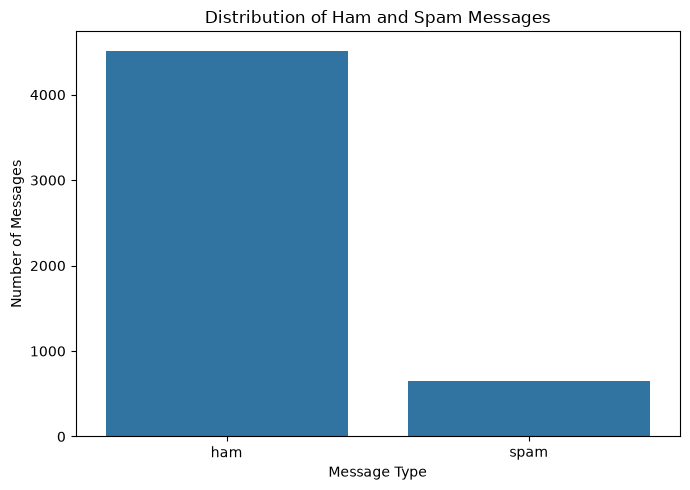

In [5]:
# Visualize class distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.tight_layout()
plt.show()

## 5. Encoding the Target Variable

Machine learning algorithms require numerical target values.

The text labels are therefore converted into binary numerical values:

- **Ham → 0**
- **Spam → 1**

The encoded values will be used as the target variable during model training.

In [6]:
# Encode target labels

df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("Label encoding completed.\n")

print(
    df[["label", "label_encoded"]].head(10)
)

Label encoding completed.

  label  label_encoded
0   ham              0
1   ham              0
2  spam              1
3   ham              0
4   ham              0
5  spam              1
6   ham              0
7   ham              0
8  spam              1
9  spam              1


## 6. Text Preprocessing

Raw text messages contain elements that are not always useful for classification, such as:

- Uppercase characters
- URLs
- Email addresses
- Numbers and special characters
- Extra whitespace

A text-cleaning function is created to standardize the messages before feature extraction.

The preprocessing steps include:

1. Convert text to lowercase
2. Remove URLs
3. Remove email addresses
4. Remove non-alphabetic characters
5. Remove extra whitespace

In [7]:
# Text preprocessing function

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Keep alphabetic characters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply text cleaning
df["clean_message"] = df["message"].apply(clean_text)

# Display original and cleaned messages
df[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling it s been week s now...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...


# Text preprocessing function

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Keep alphabetic characters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply text cleaning
df["clean_message"] = df["message"].apply(clean_text)

# Display original and cleaned messages
df[["message", "clean_message"]].head(10)

In [8]:
# Define input and target variables

X = df["clean_message"]
y = df["label_encoded"]

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

Input feature shape: (5169,)
Target shape: (5169,)


## 8. Train-Test Split

The dataset is divided into:

- **80% Training Data** — used to train the machine learning models
- **20% Testing Data** — used to evaluate their performance

Stratification is used to preserve the proportion of Spam and Ham messages in both datasets.

A fixed random state is used to make the results reproducible.

In [9]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 4135
Testing samples: 1034

Training class distribution:
label_encoded
0    3613
1     522
Name: count, dtype: int64

Testing class distribution:
label_encoded
0    903
1    131
Name: count, dtype: int64


## 9. TF-IDF Feature Extraction

Machine learning algorithms cannot directly process raw text.

**TF-IDF (Term Frequency-Inverse Document Frequency)** converts text into numerical feature vectors.

TF-IDF gives higher importance to words that are useful for distinguishing messages while reducing the importance of words that occur frequently across many messages.

The vectorizer uses:

- Unigrams and bigrams
- A minimum document frequency of 2
- English stop-word removal

The TF-IDF vocabulary is fitted only on the training data to avoid data leakage.

In [10]:
# Create TF-IDF vectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000
)

# Fit only on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the fitted vectorizer
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF transformation completed!")
print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

TF-IDF transformation completed!
Training matrix shape: (4135, 5240)
Testing matrix shape: (1034, 5240)
Vocabulary size: 5240


## 10. Model 1 — Multinomial Naive Bayes

Multinomial Naive Bayes is a commonly used algorithm for text classification.

It is particularly suitable for document and message classification because it can efficiently work with high-dimensional text features.

The model is trained using the TF-IDF representations of the training messages.

In [11]:
# Train Multinomial Naive Bayes

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes training completed!")

Multinomial Naive Bayes training completed!


## 11. Evaluating Multinomial Naive Bayes

The Naive Bayes classifier is evaluated using four important metrics:

- **Accuracy** — overall percentage of correct predictions
- **Precision** — proportion of predicted spam messages that are actually spam
- **Recall** — proportion of actual spam messages correctly detected
- **F1-Score** — harmonic mean of precision and recall

For spam detection, recall is particularly important because failing to detect an actual spam message results in a **false negative**.

In [12]:
# Evaluate Naive Bayes

nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions)
nb_recall = recall_score(y_test, nb_predictions)
nb_f1 = f1_score(y_test, nb_predictions)

print("Multinomial Naive Bayes Performance")
print("=" * 40)
print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1-Score : {nb_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=["Ham", "Spam"]
    )
)

Multinomial Naive Bayes Performance
Accuracy : 0.9681
Precision: 1.0000
Recall   : 0.7481
F1-Score : 0.8559

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       1.00      0.75      0.86       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.97      1034



## 12. Naive Bayes Confusion Matrix

A confusion matrix provides a detailed view of the classifier's predictions.

The four possible outcomes are:

- **True Negative (TN)** — Ham correctly classified as Ham
- **True Positive (TP)** — Spam correctly classified as Spam
- **False Positive (FP)** — Ham incorrectly classified as Spam
- **False Negative (FN)** — Spam incorrectly classified as Ham

False negatives are especially important in spam detection because they represent spam messages that were not detected.

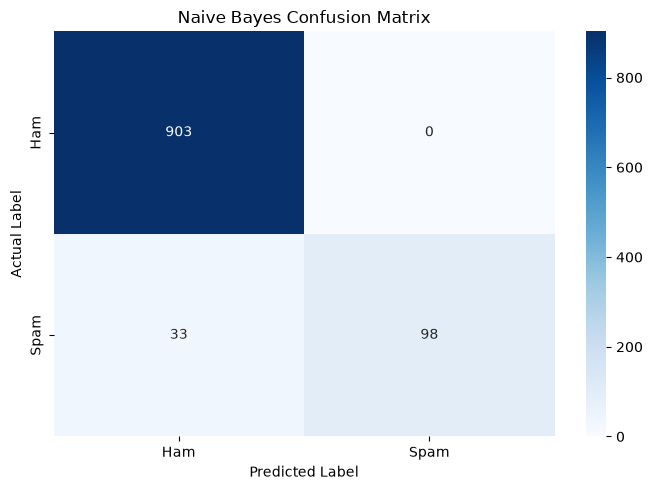

In [13]:
# Confusion matrix for Naive Bayes

nb_cm = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

## 13. Model 2 — Logistic Regression

Logistic Regression is used as a second classification algorithm for comparison.

It is widely used for binary classification and performs well with sparse, high-dimensional features such as TF-IDF text representations.

The model is trained on the same TF-IDF features used by Naive Bayes so that the comparison is fair.

In [14]:
# Train Logistic Regression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression training completed!")

Logistic Regression training completed!


## 14. Evaluating Logistic Regression

Logistic Regression is evaluated using the same metrics as Naive Bayes:

- Accuracy
- Precision
- Recall
- F1-Score

Using the same evaluation criteria allows us to compare both models objectively.

In [15]:
# Evaluate Logistic Regression

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("Logistic Regression Performance")
print("=" * 40)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        lr_predictions,
        target_names=["Ham", "Spam"]
    )
)

Logistic Regression Performance
Accuracy : 0.9507
Precision: 0.9762
Recall   : 0.6260
F1-Score : 0.7628

Classification Report:
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       0.98      0.63      0.76       131

    accuracy                           0.95      1034
   macro avg       0.96      0.81      0.87      1034
weighted avg       0.95      0.95      0.95      1034



## 15. Logistic Regression Confusion Matrix

The confusion matrix for Logistic Regression is visualized to understand the types of classification errors made by the model.

Particular attention is given to the number of **False Negatives**, because these represent spam messages incorrectly classified as legitimate messages.

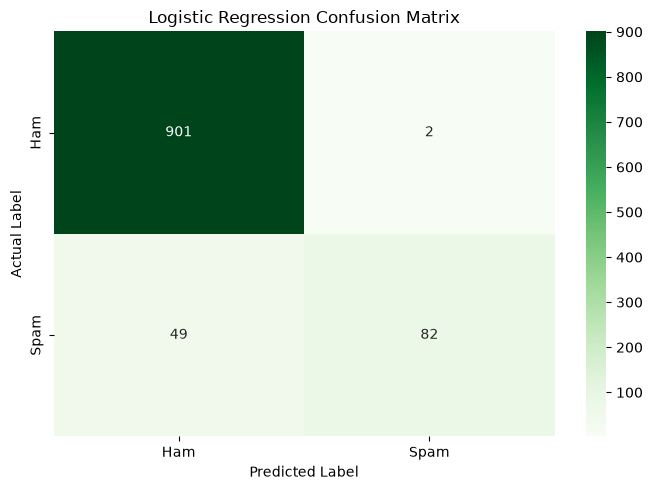

In [16]:
# Confusion matrix for Logistic Regression

lr_cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

## 16. Model Performance Comparison

Both trained models are compared using the four evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score

The comparison helps identify which model provides the most reliable overall performance for spam detection.

In [17]:
# Create model comparison table

comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall
    ],
    "F1-Score": [
        nb_f1,
        lr_f1
    ]
})

comparison = comparison.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.968085,1.00000,0.748092,0.855895
1,Logistic Regression,0.950677,0.97619,0.625954,0.762791


## 17. Visual Comparison of Model Performance

A bar chart is created to compare the performance of the two classification algorithms across Accuracy, Precision, Recall, and F1-Score.

This provides a quick visual understanding of the relative performance of the models.

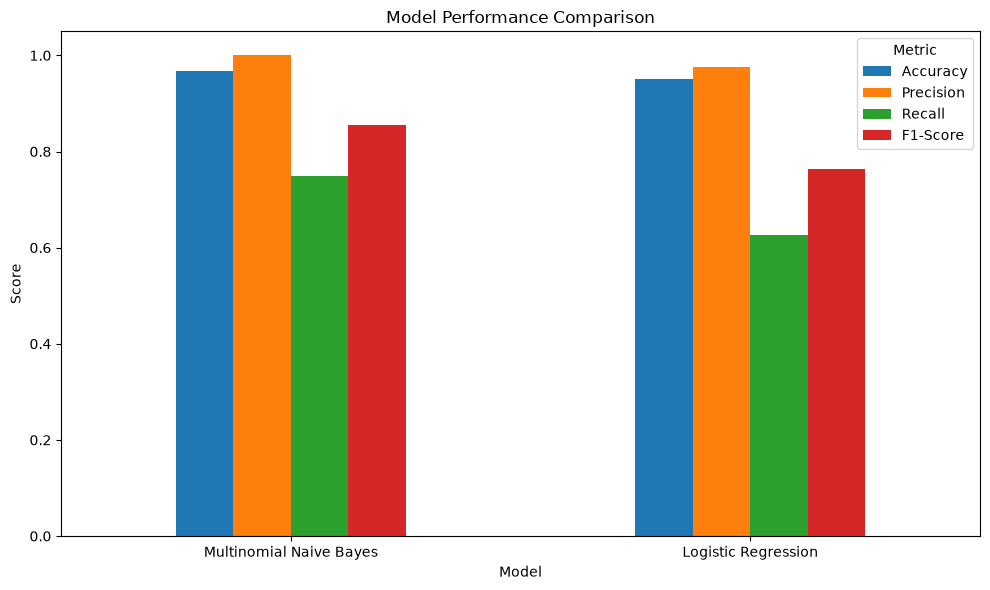

In [18]:
# Plot model performance comparison

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

comparison_plot = comparison.set_index("Model")[metrics]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 18. Selecting the Best Model

For spam detection, **F1-Score** is used as the primary criterion for model selection because it balances Precision and Recall.

Recall is also particularly important because a false negative means that an actual spam message has been incorrectly classified as legitimate.

The model with the highest F1-Score will therefore be selected as the final model.

In [19]:
# Select best model based on F1-Score

best_model_name = comparison.loc[
    comparison["F1-Score"].idxmax(),
    "Model"
]

if best_model_name == "Multinomial Naive Bayes":
    best_model = nb_model
    best_predictions = nb_predictions
else:
    best_model = lr_model
    best_predictions = lr_predictions

print("Best Model:", best_model_name)
print(
    "Best F1-Score:",
    f"{comparison.loc[comparison['Model'] == best_model_name, 'F1-Score'].iloc[0]:.4f}"
)

Best Model: Multinomial Naive Bayes
Best F1-Score: 0.8559


## 19. Error Analysis

Model evaluation metrics provide an overall performance summary, but examining individual errors can provide additional insight.

Two types of errors are particularly important:

- **False Positive:** A legitimate message is incorrectly classified as Spam.
- **False Negative:** A Spam message is incorrectly classified as Ham.

False negatives are especially important in this application because they represent unwanted messages that the spam detector failed to identify.

In [20]:
# Identify misclassified messages

error_analysis = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": best_predictions
})

error_analysis["actual_label"] = error_analysis["actual"].map({
    0: "Ham",
    1: "Spam"
})

error_analysis["predicted_label"] = error_analysis["predicted"].map({
    0: "Ham",
    1: "Spam"
})

misclassified = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
].copy()

print("Total test messages:", len(error_analysis))
print("Misclassified messages:", len(misclassified))

print("\nSample Misclassified Messages:")
misclassified[
    ["actual_label", "predicted_label", "message"]
].head(10)

Total test messages: 1034
Misclassified messages: 33

Sample Misclassified Messages:


,actual_label,predicted_label,message
1459,Spam,Ham,thanks for the vote now sing along with the st...
2697,Spam,Ham,send a logo ur lover names joined by a heart t...
484,Spam,Ham,congrats year special cinema pass for is yours...
2908,Spam,Ham,hi babe its jordan how r u im home from abroad...
1611,Spam,Ham,hi if ur lookin saucy daytime fun wiv busty ma...
4752,Spam,Ham,themob hit the link to get a premium pink pant...
1893,Spam,Ham,guess what somebody you know secretly fancies ...
5139,Spam,Ham,asked mobile if chatlines inclu in free mins i...
2802,Spam,Ham,we currently have a message awaiting your coll...
1423,Spam,Ham,hi its lucy hubby at meetins all day fri i wil...


In [21]:
# Identify misclassified messages

error_analysis = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": best_predictions
})

error_analysis["actual_label"] = error_analysis["actual"].map({
    0: "Ham",
    1: "Spam"
})

error_analysis["predicted_label"] = error_analysis["predicted"].map({
    0: "Ham",
    1: "Spam"
})

misclassified = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
].copy()

print("Total test messages:", len(error_analysis))
print("Misclassified messages:", len(misclassified))

print("\nSample Misclassified Messages:")
misclassified[
    ["actual_label", "predicted_label", "message"]
].head(10)

Total test messages: 1034
Misclassified messages: 33

Sample Misclassified Messages:


,actual_label,predicted_label,message
1459,Spam,Ham,thanks for the vote now sing along with the st...
2697,Spam,Ham,send a logo ur lover names joined by a heart t...
484,Spam,Ham,congrats year special cinema pass for is yours...
2908,Spam,Ham,hi babe its jordan how r u im home from abroad...
1611,Spam,Ham,hi if ur lookin saucy daytime fun wiv busty ma...
4752,Spam,Ham,themob hit the link to get a premium pink pant...
1893,Spam,Ham,guess what somebody you know secretly fancies ...
5139,Spam,Ham,asked mobile if chatlines inclu in free mins i...
2802,Spam,Ham,we currently have a message awaiting your coll...
1423,Spam,Ham,hi its lucy hubby at meetins all day fri i wil...


## 20. Word Frequency Analysis

Examining frequently occurring words can provide useful insights into the language used in the dataset.

Spam messages often contain promotional, financial, prize-related, or urgency-related terms, while Ham messages tend to contain more conversational language.

The following analysis identifies frequently occurring words separately for Ham and Spam messages.

In [22]:
from collections import Counter

# Extract words from cleaned messages

ham_text = " ".join(
    df.loc[df["label"] == "ham", "clean_message"]
)

spam_text = " ".join(
    df.loc[df["label"] == "spam", "clean_message"]
)

ham_words = Counter(ham_text.split())
spam_words = Counter(spam_text.split())

print("Top 20 Ham Words:")
print(ham_words.most_common(20))

print("\nTop 20 Spam Words:")
print(spam_words.most_common(20))

Top 20 Ham Words:
[('i', 2795), ('you', 1880), ('to', 1481), ('the', 1066), ('a', 978), ('u', 938), ('and', 826), ('in', 764), ('me', 732), ('my', 680), ('it', 664), ('is', 656), ('that', 547), ('for', 481), ('s', 481), ('of', 479), ('have', 426), ('so', 421), ('can', 421), ('but', 420)]

Top 20 Spam Words:
[('to', 599), ('a', 346), ('call', 322), ('you', 270), ('your', 242), ('free', 197), ('for', 185), ('the', 183), ('now', 168), ('or', 160), ('u', 151), ('p', 148), ('is', 144), ('txt', 137), ('from', 123), ('on', 122), ('ur', 119), ('stop', 116), ('have', 115), ('mobile', 111)]


## 21. Most Common Words in Ham Messages

The following visualization shows the most frequently occurring words in legitimate messages.

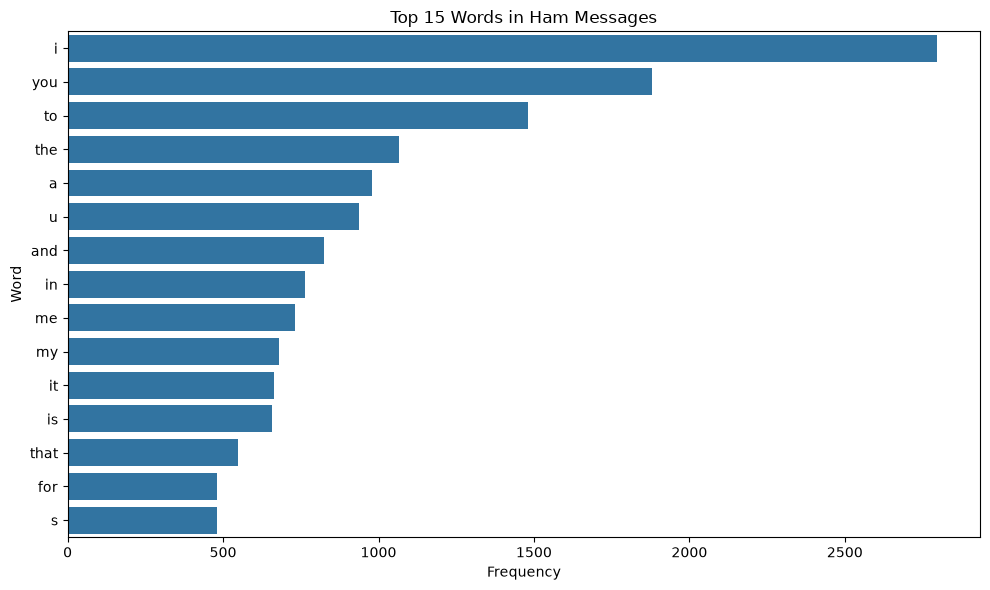

In [23]:
# Top words in Ham messages

ham_top = pd.DataFrame(
    ham_words.most_common(15),
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=ham_top,
    x="Frequency",
    y="Word"
)

plt.title("Top 15 Words in Ham Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

## 22. Most Common Words in Spam Messages

The following visualization shows the most frequently occurring words in spam messages.

These terms can help demonstrate the linguistic characteristics of unwanted messages in the dataset.

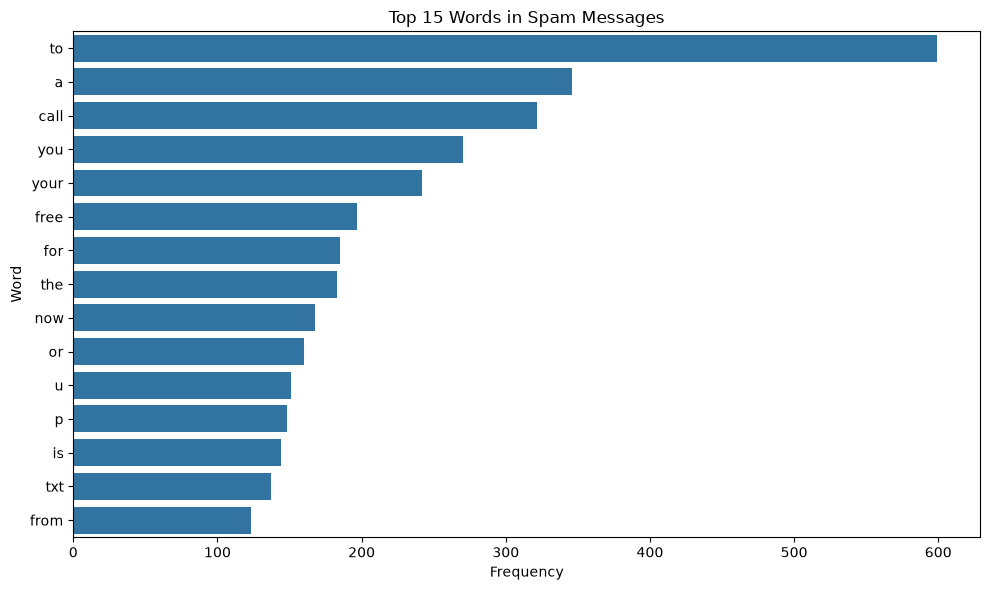

In [24]:
# Top words in Spam messages

spam_top = pd.DataFrame(
    spam_words.most_common(15),
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=spam_top,
    x="Frequency",
    y="Word"
)

plt.title("Top 15 Words in Spam Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

## 23. Final Model Evaluation

The selected model is evaluated once more using a complete classification report.

The report provides class-wise Precision, Recall, F1-Score, and Support for both Ham and Spam classes.

In [25]:
# Final classification report

print("Final Model:", best_model_name)
print("=" * 60)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Ham", "Spam"],
        digits=4
    )
)

Final Model: Multinomial Naive Bayes
              precision    recall  f1-score   support

         Ham     0.9647    1.0000    0.9821       903
        Spam     1.0000    0.7481    0.8559       131

    accuracy                         0.9681      1034
   macro avg     0.9824    0.8740    0.9190      1034
weighted avg     0.9692    0.9681    0.9661      1034



## 24. Saving the Model and TF-IDF Vectorizer

To use the trained spam detector later in a Streamlit application, both the trained classification model and the fitted TF-IDF vectorizer must be saved.

The vectorizer is necessary because new messages must be transformed into the same numerical feature representation used during model training.

In [26]:
# Create model directory

MODEL_DIR = Path("DataScience-Task4-EmailSpamDetection/model")

if not MODEL_DIR.exists():
    MODEL_DIR = Path("model")

MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save the trained model
model_path = MODEL_DIR / "spam_classifier.pkl"

# Save TF-IDF vectorizer
vectorizer_path = MODEL_DIR / "tfidf_vectorizer.pkl"

joblib.dump(best_model, model_path)
joblib.dump(tfidf, vectorizer_path)

print("Model saved to:")
print(model_path)

print("\nTF-IDF vectorizer saved to:")
print(vectorizer_path)

Model saved to:
model\spam_classifier.pkl

TF-IDF vectorizer saved to:
model\tfidf_vectorizer.pkl


## 25. Testing the Saved Model

The saved model and TF-IDF vectorizer are loaded again to verify that the serialized files can correctly perform predictions.

This ensures that the model can later be used independently by the Streamlit application.

In [27]:
# Reload saved model and vectorizer

loaded_model = joblib.load(model_path)
loaded_vectorizer = joblib.load(vectorizer_path)

# Test messages

test_messages = [
    "Congratulations! You have won a free prize. Call now!",
    "Hey, are we still meeting for dinner tonight?"
]

# Clean messages
clean_test_messages = [
    clean_text(message)
    for message in test_messages
]

# Convert to TF-IDF
test_features = loaded_vectorizer.transform(
    clean_test_messages
)

# Predict
test_predictions = loaded_model.predict(test_features)

print("Saved model test results:")
print("=" * 50)

for message, prediction in zip(test_messages, test_predictions):

    result = "SPAM" if prediction == 1 else "HAM"

    print(f"\nMessage: {message}")
    print(f"Prediction: {result}")

Saved model test results:

Message: Congratulations! You have won a free prize. Call now!
Prediction: SPAM

Message: Hey, are we still meeting for dinner tonight?
Prediction: HAM


## 26. Conclusion

This project developed a machine learning-based spam detection system using Natural Language Processing.

The workflow included:

- Dataset exploration and cleaning
- Duplicate removal
- Text preprocessing
- TF-IDF feature extraction
- Train-test splitting
- Multinomial Naive Bayes classification
- Logistic Regression classification
- Accuracy, Precision, Recall and F1-Score evaluation
- Confusion matrix analysis
- Error analysis
- Word-frequency analysis
- Model comparison
- Selection of the best-performing classifier
- Model and TF-IDF vectorizer serialization

### Key Findings

The comparison of the two classifiers provides a basis for selecting a suitable spam detection model. F1-Score was used as the primary selection criterion because it balances Precision and Recall.

Recall is particularly important for this application because false negatives represent spam messages that are incorrectly classified as legitimate.

The saved model and TF-IDF vectorizer can be integrated into a Streamlit application to provide real-time spam classification for new messages.

## 27. Future Improvements

The project can be further improved by:

- Testing additional NLP preprocessing techniques
- Using stemming or lemmatization
- Experimenting with different TF-IDF configurations
- Testing additional classification algorithms
- Performing hyperparameter tuning
- Using word embeddings or transformer-based models
- Adding probability/confidence scores to the dashboard
- Expanding the dataset with additional spam examples
- Deploying the application as an interactive web service

## 28. Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib
- Jupyter Notebook
- Streamlit

### Machine Learning Techniques

- Text preprocessing
- TF-IDF Vectorization
- Multinomial Naive Bayes
- Logistic Regression
- Binary Classification
- Model Evaluation